# Sparse visual features across datasets

Native Overcomplete models and pretrained RA-SAE / Prisma transcoder.
All fitting and extraction live in `src/lattmc/vision`.
Classes and patch positions do not constrain shared features.
Exploratory annotation-guided images are separate from evaluation.

In [1]:
import json
import sys
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

root = Path.cwd()
sys.path.insert(0, str(root / "src"))
folder = root / "vision_tokens/overcomplete"
summary = json.loads(
    (folder / "results/summary_codexgen.json").read_text())
verification = json.loads(
    (folder / "results/verification_codexgen.json")
    .read_text())
verification

{'evaluated_model_dataset_pairs': 73,
 'verified_query_closures': 1168,
 'independent_image_position_permutations': 1168,
 'within_dataset_exact_crop_split_leakage': False,
 'exact_duplicate_crop_groups': [],
 'source_width_and_syntax': 'passed',
 'native_adapter_checks': 'passed'}

## Reconstruction and measured sparsity

Pretrained and local fits differ in width and training data.
The transcoder predicts a different target from the SAEs.
Bootstrap intervals resample images in these fixed subsets.

In [2]:
pd.DataFrame(summary["transfer"])

,model,dataset,images,r2,l0,image_bootstrap_95,skip_only_r2
0,topk_k32_s0,imagenette,100,0.616471,32.000000,"[0.5963389088488359, 0.6379178168155698]",NaN
1,topk_k32_s0,imagewoof,100,0.447513,32.000000,"[0.4370567989595904, 0.4578895624280521]",NaN
2,topk_k32_s0,pets,200,0.418101,32.000000,"[0.40627310806662725, 0.4301134130535607]",NaN
3,topk_k32_s0,parts,53,0.351221,32.000000,"[0.32318434932855494, 0.38288058027835564]",NaN
4,topk_k32_s0,dtd,94,0.272329,32.000000,"[0.2599751144875864, 0.28463795912530643]",NaN
5,batchtopk_k32_s0,imagenette,100,0.639824,47.436211,"[0.622188521254372, 0.6582562487980028]",NaN
6,batchtopk_k32_s0,imagewoof,100,0.485077,58.097852,"[0.4753407911745253, 0.494830716984623]",NaN
7,batchtopk_k32_s0,pets,200,0.458455,60.028418,"[0.4475865599876949, 0.46928921547754343]",NaN
8,batchtopk_k32_s0,parts,53,0.394869,61.485259,"[0.36817590180261595, 0.4243574061507955]",NaN
9,batchtopk_k32_s0,dtd,94,0.331542,66.393534,"[0.31938830262994006, 0.34358402559495216]",NaN


## Stability

Decoder cosine matching and image-extent overlap are distinct.
Archetypal fits share landmarks and mixing initialization.

In [3]:
pd.DataFrame(summary["stability"])

,family,budget,seed_pair,decoder_cosine,extent_jaccard,nonempty_comparisons
0,topk,16,"[0, 1]",0.378839,0.346111,1156
1,topk,16,"[0, 2]",0.381670,0.344046,1162
2,topk,32,"[0, 1]",0.332465,0.323905,1484
3,topk,32,"[0, 2]",0.333337,0.328939,1485
4,batchtopk,16,"[0, 1]",0.358887,0.349357,1067
5,batchtopk,16,"[0, 2]",0.357777,0.352064,1058
6,batchtopk,32,"[0, 1]",0.330942,0.334143,1494
7,batchtopk,32,"[0, 2]",0.330141,0.335202,1493
8,jump,16,"[0, 1]",0.286830,0.320568,1267
9,jump,16,"[0, 2]",0.283962,0.310025,1269


## Training-selected TopK features

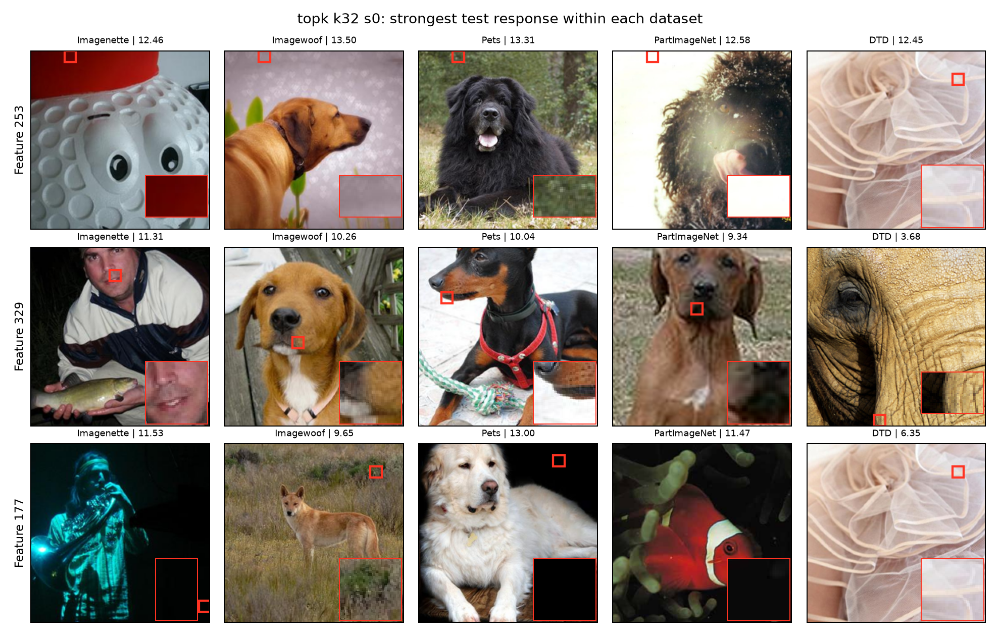

In [4]:
path = (folder / "figures" /
        "topk_k32_s0_gallery_codexgen.png")
display(Image(filename=str(path)))

## Exploratory foreground-associated pretrained features; selection
uses test annotations and is not an unbiased evaluation

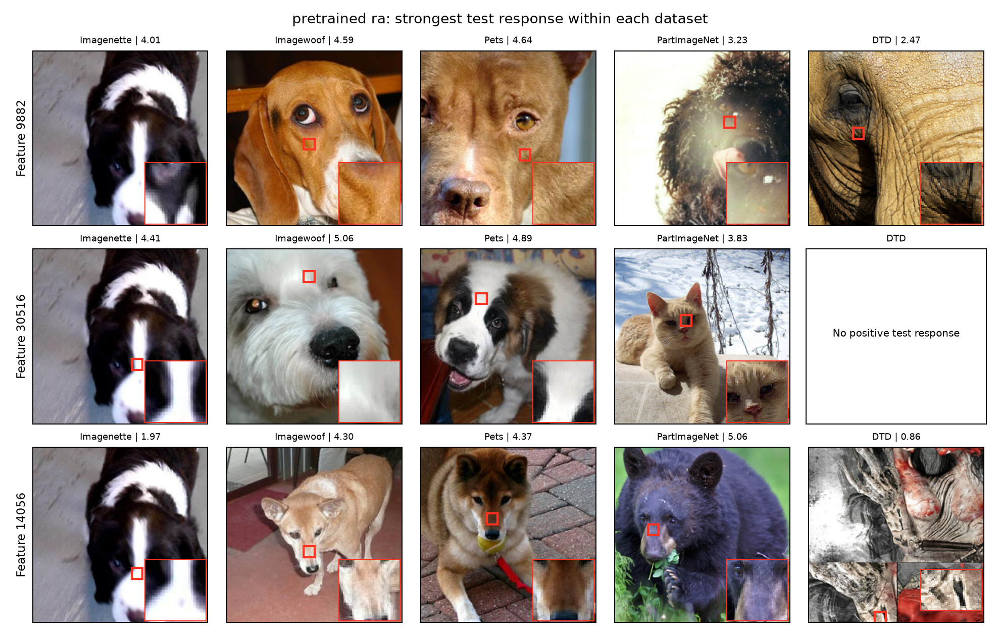

In [5]:
path = (folder / "figures" /
        "pretrained_ra_foreground_gallery_codexgen.png")
display(Image(filename=str(path)))

## Training-selected transcoder features

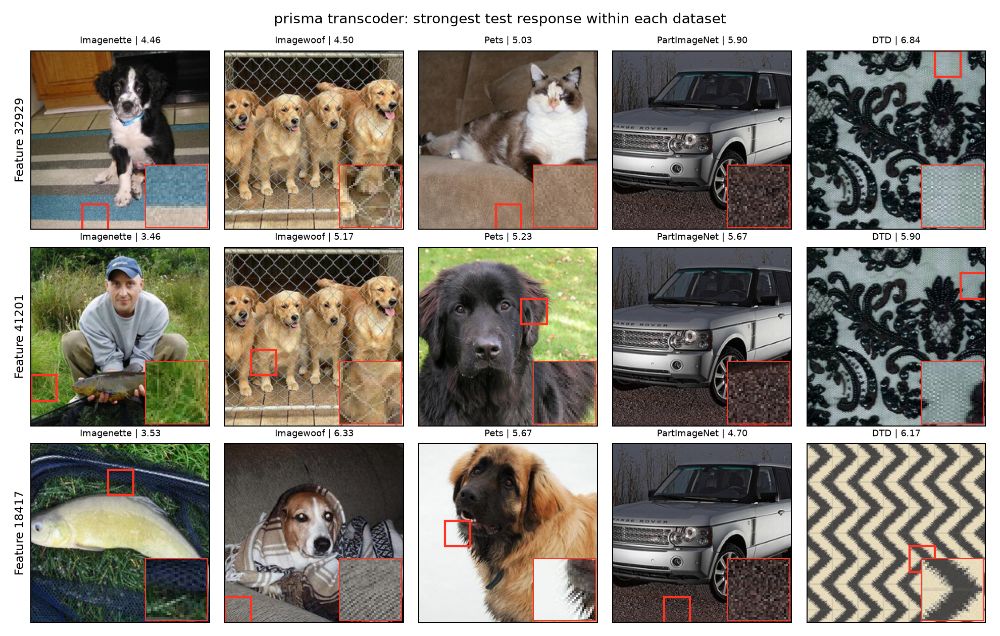

In [6]:
path = (folder / "figures" /
        "prisma_transcoder_gallery_codexgen.png")
display(Image(filename=str(path)))

## Frozen meet/join queries; patch locations may differ

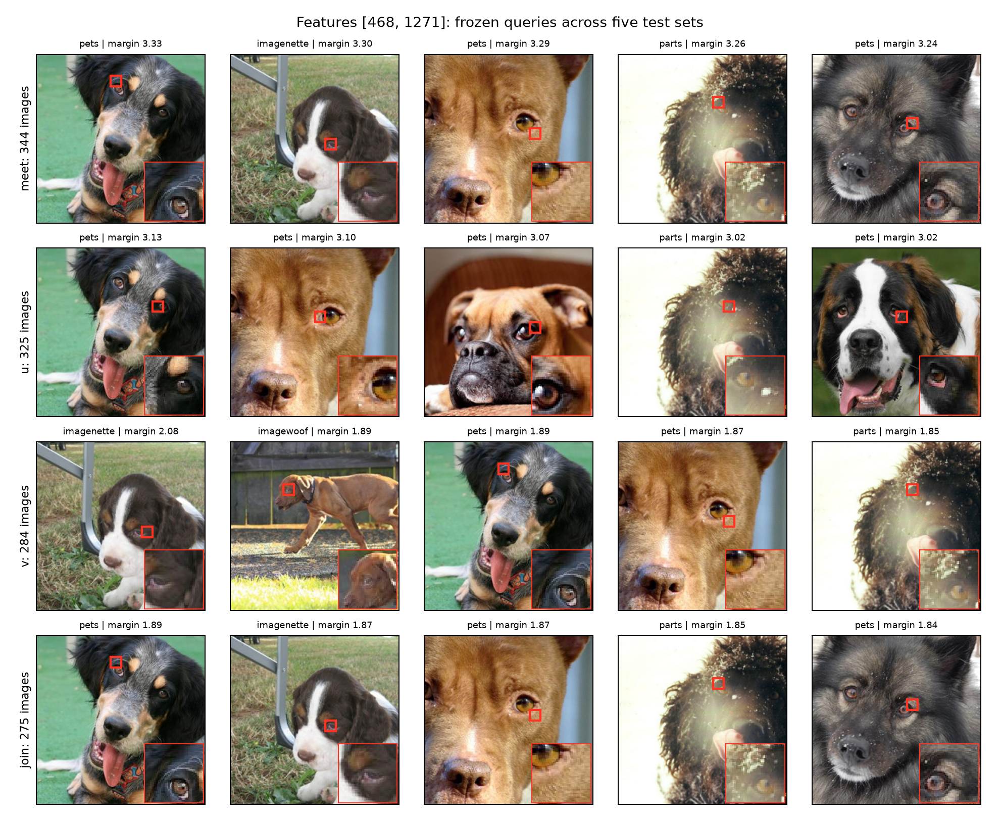

In [7]:
path = (folder / "figures" /
        "meet_join_codexgen.png")
display(Image(filename=str(path)))

## Fixed-contrast gratings and frequency-matched control coordinates

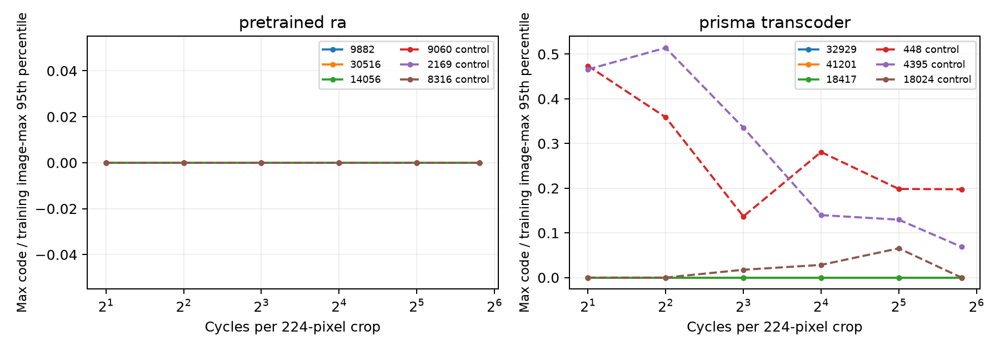

In [8]:
path = (folder / "figures" /
        "frequency_probe_codexgen.png")
display(Image(filename=str(path)))